# Classification Exploration

Exploring the dataset and variables to see if using a classification model would be apropriate to answer the predictive question

In [1]:
library(tidyverse)
library(repr)
library(tidymodels)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
── Attaching packages ────────────────────────────────────── tidymodels 1.1.1 ──

✔ broom        1.0.6     ✔ rsample      1.2.1
✔ dials        1.3.0     ✔ tune         1.1.2
✔ infer        1.0.7     ✔ workflows    1.1.4
✔ modeldata    1.4.0     ✔ workflowsets 1.0.1
✔ parsnip      1.2.1     ✔ yardstick    1.3.1
✔ recipes      1.1.0     

── Conflicts ───────────────────────────────────────── tidymodels_conflicts() ──
✖ scales::discard() masks purrr::discard()
✖ dplyr::filt

In [12]:
players <- read_csv("https://raw.githubusercontent.com/YodawgYT/Assignment-Project-Final-Report---GROUP-39---DSCI-100/refs/heads/main/data/players.csv") |>
        mutate(subscribe = as_factor(subscribe), age = Age) |>
        select(experience, subscribe, played_hours, gender, age) 
head(players)

Rows: 196 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): experience, hashedEmail, name, gender
dbl (2): played_hours, Age
lgl (1): subscribe

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


experience,subscribe,played_hours,gender,age
<chr>,<fct>,<dbl>,<chr>,<dbl>
Pro,TRUE,30.3,Male,9
Veteran,TRUE,3.8,Male,17
Veteran,FALSE,0.0,Male,17
Amateur,TRUE,0.7,Female,21
Regular,TRUE,0.1,Male,21
Amateur,TRUE,0.0,Female,17


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


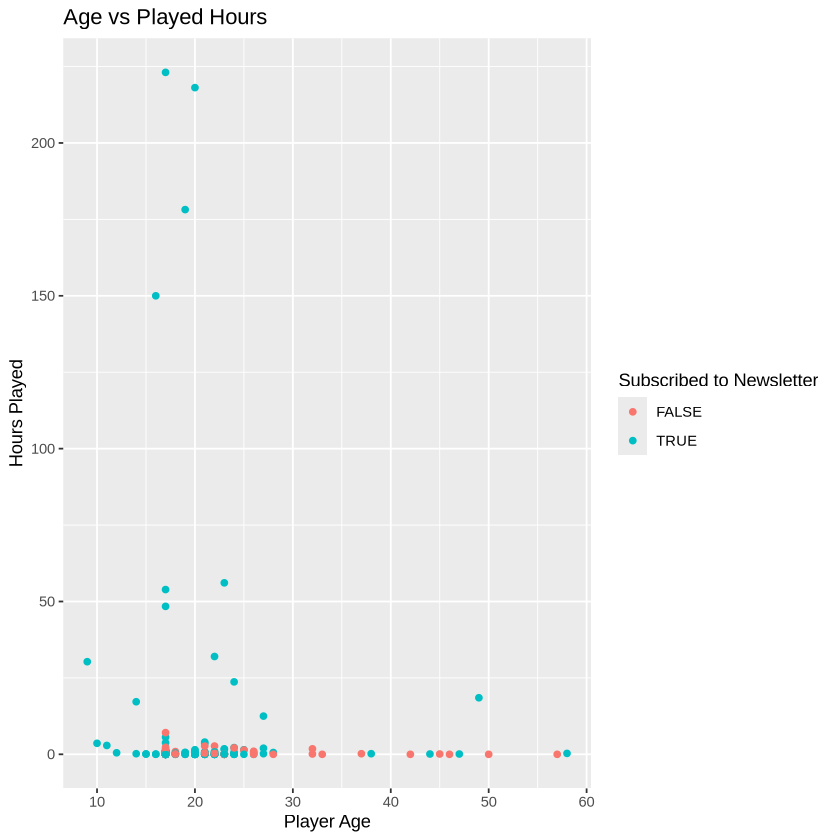

In [3]:
players_plot1 <- players |>
        ggplot(aes(x = age, y = played_hours, color = subscribe)) +
        geom_point() +
        labs(x = "Player Age",
             y = "Hours Played",
             color = "Subscribed to Newsletter",
             title = "Age vs Played Hours")
players_plot1

In [4]:
set.seed(99)
players_split <- initial_split(players, prop = .75, strata = subscribe)
players_training <- training(players_split)
players_testing <- testing(players_split)

→ A | error:   Assigned data `orig_rows` must be compatible with existing data.
               ✖ Existing data has 29 rows.
               ✖ Assigned data has 30 rows.
               ℹ Only vectors of size 1 are recycled.
               Caused by error in `vectbl_recycle_rhs_rows()`:
               ! Can't recycle input of size 30 to size 29.

There were issues with some computations   A: x1

→ B | error:   Assigned data `orig_rows` must be compatible with existing data.
               ✖ Existing data has 28 rows.
               ✖ Assigned data has 29 rows.
               ℹ Only vectors of size 1 are recycled.
               Caused by error in `vectbl_recycle_rhs_rows()`:
               ! Can't recycle input of size 29 to size 28.

There were issues with some computations   A: x1
There were issues with some computations   A: x1   B: x1





neighbors,.metric,mean
<dbl>,<chr>,<dbl>
1,accuracy,0.3404762
2,accuracy,0.3293651
3,accuracy,0.4738095
4,accuracy,0.4182540
5,accuracy,0.4079365
6,accuracy,0.4079365
7,accuracy,0.5301587
8,accuracy,0.5079365
9,accuracy,0.4984127


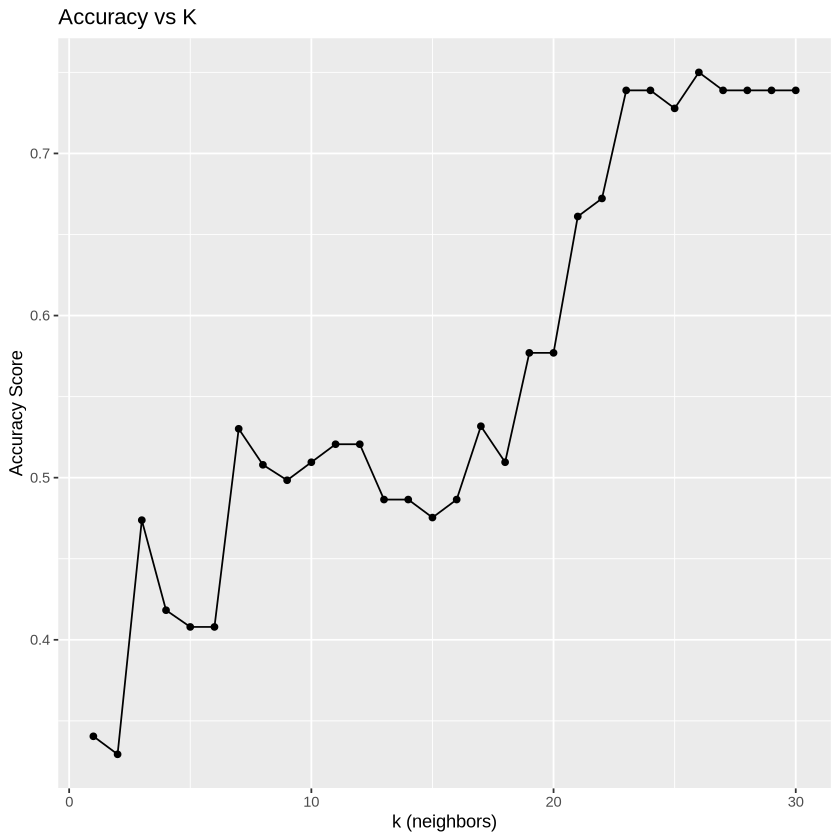

In [10]:
set.seed(99)
players_recipe <- recipe(subscribe ~ age, data = players_training)

players_folds <- vfold_cv(players_training, v = 5, strata = subscribe)

knn_tune <- nearest_neighbor(weight_func = "rectangular", neighbors = tune()) |>
set_engine("kknn") |>
set_mode("classification")

k_vals <- tibble(neighbors = seq(from = 1, to = 30, by = 1))

players_fit <- workflow() |>
add_recipe(players_recipe) |>
add_model(knn_tune) |>
tune_grid(resamples = players_folds, grid = k_vals) |>
collect_metrics()

accuracies <- players_fit |>
filter(.metric == "accuracy")|>
select(neighbors, .metric, mean)
accuracies

cross_val_plot <- ggplot(accuracies, aes(x = neighbors, y = mean) ) +
geom_point () +
geom_line() +
labs (x = "k (neighbors)", y = "Accuracy Score", title = "Accuracy vs K")
cross_val_plot

In [6]:
set.seed(99)

players_spec <- nearest_neighbor(weight_func = "rectangular", neighbors = 26) |>
set_engine("kknn") |>
set_mode("classification")

players_fit_best <- players_spec |>
  fit(subscribe ~ age, data = players_training)

players_predictions <- predict(players_fit_best, players_testing) |>
                    bind_cols(players_testing)

players_metrics <- players_predictions |>
     metrics(truth = subscribe, estimate = .pred_class) |>
     filter(.metric == "accuracy")
players_metrics

players_conf_mat <- players_predictions |>
     conf_mat(truth = subscribe, estimate = .pred_class)
players_conf_mat

.metric,.estimator,.estimate
<chr>,<chr>,<dbl>
accuracy,binary,0.755102


          Truth
Prediction FALSE TRUE
     FALSE     1    0
     TRUE     12   36